# M4 | Research Investigation Notebook

In this notebook, you will do a research investigation of your chosen dataset in teams. You will begin by formally selecting your research question (task 0), then processing your data (task 1), creating a predictive model (task 2), evaluating your model's results (task 3), and describing the contributions of each team member (task 4).

For grading, please make sure your notebook has all cells already run. You will also need to write a short, 2 page report about your design decisions as a team, to be uploaded to Moodle in the form of a PDF file next to this Jupyter notebook.

You should provide arguments and justifications for all of your design decisions throughout this investigation. You can use your M3 responses as the basis for this discussion.

In [1]:
# Import the tables of the data set as dataframes.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = './data' # You many change the directory

# Other main package imports
import seaborn as sns
import scipy as sc

# Scikit-learn package imports
from sklearn import feature_extraction, model_selection
from sklearn.metrics import root_mean_squared_error, mean_squared_error, roc_auc_score

# PyBKT package imports
import random
old_randint = random.randint
random.randint = lambda a, b: old_randint(a, int(b))
from pyBKT.models import Model
random.randint = old_randint

## Task 0: Research Question

**Research question:**
*How does AI model usage by students affect their learning?*

## Task 1: Data Preprocessing

In this section, you are asked to preprocess your data in a way that is relevant for the model. Please include 1-2 visualizations of features / data explorations that are related to your downstream prediction task.

In [2]:
# 1. Map Gymitrainer data to rest of tables 
gymitrainer_df = pd.read_csv("/home/mlbd-project/data/gymitrainer.csv")
gymitrainer_df = gymitrainer_df.drop(columns=['chat_profile'])
#display(gymitrainer_df.head())
mapping_df = pd.read_csv("/home/mlbd-project/data/mapping.csv")
#display(mapping_df.head())

threshold = 0.5
filtered_mapping = mapping_df[mapping_df['confidence'] >= threshold]

# Contains only users where the matching is confident enough and who 
# used the chatbot at all (since they appear in gymitrainer.csv)
# Inner merging guarantees that we only have people who used the chatbot
matched_gymitrainer = pd.merge(
    gymitrainer_df,
    filtered_mapping[['id', 'user_id']],
    on='id',
    how='inner'  
)

tag_replacements = {
    'Mathehilfe': 'Mathe',
    'math_help': 'Mathe',
    'essay_writing': 'Aufsatz',
    'Aufsatzhilfe': 'Aufsatz',
    'Sprachprufung': 'Sprache',
    'text_comprehension': 'Sprache'
}

matched_gymitrainer['tag'] = matched_gymitrainer['tag'].replace(tag_replacements)

def fill_missing_tag(row):
    if pd.isna(row['tag']) or row['tag'] == '':
        content = str(row['content'])
        if content.startswith("['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor") or \
           content.startswith("['Hallo! Mein Name ist Gymitrainer, und ich bin dein Mathe-Guru"):
            return 'Mathe'
        elif content.startswith("['Hey! Ich bin Gymitrainer, dein Experte für Gymi-Prüfungsaufsätze"):
            return 'Aufsatz'
        else:
            return row['tag']
    else:
        return row['tag']

matched_gymitrainer['tag'] = matched_gymitrainer.apply(fill_missing_tag, axis=1)

matched_gymitrainer = matched_gymitrainer.sort_values(by='user_id')
display(matched_gymitrainer.head())   



# 2. Remove potential teachers from the dataset as a safety 
# (we only want to study learning on students)
teachers = pd.read_csv("/home/mlbd-project/data/teachers.csv")
teacher_ids = teachers['user_id'].unique()
matched_gymitrainer = matched_gymitrainer[~matched_gymitrainer['user_id'].isin(teacher_ids)].copy()



# 3. Clean and prepare the datasets by subjects 
math_results = pd.read_csv("/home/mlbd-project/data/math_results.csv")
math_questions_clean = pd.read_csv("/home/mlbd-project/data/math_questions_clean.csv")
math_results['question'] = math_results['question'].astype(str)
math_questions_clean['question_id'] = math_questions_clean['question_id'].astype(str)
math_results_clean = math_results[
    math_results['question'].isin(math_questions_clean['question_id'])
] 
math_results_clean = math_results_clean.merge(
    math_questions_clean[['question_id', 'skill_id']],
    left_on='question',
    right_on='question_id',
    how='left'
)
math_results_clean = math_results_clean.drop(columns=['question_id'])
#math_results_clean['timestamp'] = pd.to_datetime(math_results_clean['time'], unit='s')
math_results_clean['timestamp'] = math_results_clean['time'].astype(int)
math_results_clean['correct'] = math_results_clean['correct'].astype(int)
math_results_clean['hint_used'] = (math_results_clean['hint_count'] > 0).astype(int)

# essay_results = pd.read_csv("/home/mlbd-project/data/essay_results.csv")
# essay_results_clean = essay_results.copy()
# essay_results_clean['timestamp'] = pd.to_datetime(essay_results_clean['time'], unit='s')
# essay_skill_columns = [col for col in essay_results.columns if '-' in col or col.startswith('content') or col.startswith('structure') or col.startswith('language')]
# essay_results_clean['skill_score'] = essay_results_clean[essay_skill_columns].mean(axis=1)
# essay_results_clean['correct'] = (essay_results_clean['skill_score'] >= 6).astype(int)
# essay_results_clean['skill_id'] = essay_results_clean['textType']  # Treat text type (e.g. "erzaehlung") as a skill

# text_results = pd.read_csv("/home/mlbd-project/data/text_results.csv")
# text_results_clean = text_results.copy()
# text_results_clean['timestamp'] = pd.to_datetime(text_results_clean['time'], unit='s')
# text_results_clean['skill_id'] = text_results_clean['exam_id'].astype(str) + '-' + text_results_clean['question'].astype(str)
# text_results_clean['correct'] = (text_results_clean['points'] / text_results_clean['max_points']) >= 0.5
# text_results_clean['correct'] = text_results_clean['correct'].astype(int) 

math_data = math_results_clean[['user_id', 'skill_id', 'correct', 'timestamp', 'hint_used']]
# essay_data = essay_results_clean[['user_id', 'skill_id', 'correct', 'timestamp']]
# text_data = text_results_clean[['user_id', 'skill_id', 'correct', 'timestamp']]

# essay_data.loc[:, 'hint_used'] = 0
# text_data.loc[:, 'hint_used'] = 0



# 4. Define AI usage for each user, by subject (a heavy AI user in Essays might not be a heavy AI 
# user in Math, and the criteria shall not be the same as users send many more messages on average
# to Gymitrainer for Math than for other subjects)
subject_tags = ['Mathe', 'Aufsatz', 'Sprache']

ai_usage_per_subject = matched_gymitrainer[matched_gymitrainer['tag'].isin(subject_tags)].groupby(['user_id', 'tag']).size().unstack(fill_value=0)

for subject in subject_tags:
    if subject not in ai_usage_per_subject.columns:
        ai_usage_per_subject[subject] = 0

print("# of Messages for each User, by Subject", ai_usage_per_subject.head())

def compute_threshold(series, percentile=75):
    non_zero = series[series > 0]
    return np.percentile(non_zero, percentile) if len(non_zero) > 0 else 0

def categorize_usage(count, threshold):
    if count == 0:
        return 'non_ai_user'
    elif count <= threshold:
        return 'light_ai_user'
    else:
        return 'heavy_ai_user'

cutoff_percentile = 75

for subject in subject_tags:
    threshold = compute_threshold(ai_usage_per_subject[subject], percentile=cutoff_percentile)
    ai_usage_per_subject[f'{subject}_ai_usage_category'] = ai_usage_per_subject[subject].apply(
        lambda x: categorize_usage(x, threshold)
    )

print("# of Messages for each User, by Subject", ai_usage_per_subject[[f'{s}_ai_usage_category' for s in subject_tags]].head())



# 5. Create dataframes that contain info on a user's AI usage
math_data_with_ai = math_data.merge(
    ai_usage_per_subject[['Mathe', 'Mathe_ai_usage_category']], 
    on='user_id', 
    how='left'
)

# essay_data_with_ai = essay_data.merge(
#     ai_usage_per_subject[['Aufsatz', 'Aufsatz_ai_usage_category']], 
#     on='user_id', 
#     how='left'
# )

# text_data_with_ai = text_data.merge(
#     ai_usage_per_subject[['Sprache', 'Sprache_ai_usage_category']], 
#     on='user_id', 
#     how='left'
# )

math_data_with_ai['Mathe'] = math_data_with_ai['Mathe'].fillna(0)
math_data_with_ai['Mathe_ai_usage_category'] = math_data_with_ai['Mathe_ai_usage_category'].fillna('non_ai_user')

# essay_data_with_ai['Aufsatz'] = essay_data_with_ai['Aufsatz'].fillna(0)
# essay_data_with_ai['Aufsatz_ai_usage_category'] = essay_data_with_ai['Aufsatz_ai_usage_category'].fillna('non_ai_user')

# text_data_with_ai['Sprache'] = text_data_with_ai['Sprache'].fillna(0)
# text_data_with_ai['Sprache_ai_usage_category'] = text_data_with_ai['Sprache_ai_usage_category'].fillna('non_ai_user')

math_data_categorical = math_data_with_ai.sort_values(
    by=['user_id', 'timestamp'],
    ascending=[True, True]
).reset_index(drop=True)

# essay_data_categorical = essay_data_with_ai.sort_values(
#     by=['user_id', 'timestamp'],
#     ascending=[True, True]
# ).reset_index(drop=True)

# text_data_categorical = text_data_with_ai.sort_values(
#     by=['user_id', 'timestamp'],
#     ascending=[True, True]
# ).reset_index(drop=True)



# 6. Add order_id column that orders a user-id's submissions by skill and time
math_data_categorical['order_id'] = math_data_categorical.groupby('user_id').cumcount() + 1
# essay_data_categorical['order_id'] = essay_data_categorical.groupby('user_id').cumcount() + 1
# text_data_categorical['order_id'] = text_data_categorical.groupby('user_id').cumcount() + 1



# 7. Extra columns added to use for AFM/PFA
def preprocess_data(data):
    data = data.copy()  # Avoid modifying a slice of the original DataFrame
    data.loc[:, 'aux'] = 1
    data.loc[:, 'prev_attempts'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['aux'].cumsum() - 1

    # Number of correct and incorrect attempts before current attempt
    data.loc[:, 'correct_aux'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['correct'].cumsum()
    data.loc[:, 'before_correct_num'] = data.sort_values('order_id').groupby(['user_id', 'skill_id'])['correct_aux'].shift(periods=1, fill_value=0)
    data.loc[:, 'before_wrong_num'] = data['prev_attempts'] - data['before_correct_num']
    return data

math_data_categorical = preprocess_data(math_data_categorical)
# essay_data_categorical = preprocess_data(essay_data_categorical)
# text_data_categorical = preprocess_data(text_data_categorical)



# 7. Visualizations

print("Math data example:")
display(math_data_categorical.head(30))

# print("Essay data example:")
# display(essay_data_categorical.head())

# print("Text data example:")
# display(text_data_categorical.head())



# 8. Datasets cut by AI Usage for training

df_non_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'non_ai_user'].drop(columns='Mathe_ai_usage_category')
df_light_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'light_ai_user'].drop(columns='Mathe_ai_usage_category')
df_heavy_ai_math = math_data_categorical[math_data_categorical['Mathe_ai_usage_category'] == 'heavy_ai_user'].drop(columns='Mathe_ai_usage_category')

# df_non_ai_essay = essay_data_categorical[essay_data_categorical['ai_usage_category'] == 'non_ai_user'].drop(columns='ai_usage_category')
# df_light_ai_essay = essay_data_categorical[essay_data_categorical['ai_usage_category'] == 'light_ai_user'].drop(columns='ai_usage_category')
# df_heavy_ai_essay = essay_data_categorical[essay_data_categorical['ai_usage_category'] == 'heavy_ai_user'].drop(columns='ai_usage_category')

# df_non_ai_text = text_data_categorical[text_data_categorical['ai_usage_category'] == 'non_ai_user'].drop(columns='ai_usage_category')
# df_light_ai_text = text_data_categorical[text_data_categorical['ai_usage_category'] == 'light_ai_user'].drop(columns='ai_usage_category')
# df_heavy_ai_text = text_data_categorical[text_data_categorical['ai_usage_category'] == 'heavy_ai_user'].drop(columns='ai_usage_category')

display(df_non_ai_math.head(30))

,Unnamed: 0,id,tag,message_count,startTime,endTime,content,user_id
1630,4454,321dae4e-6d92-40be-b780-232cecf3b586,NaN,1,1730219336,1730219336,['wie soll ich das rechnen'],4
1629,4453,74677c94-340b-4017-9cba-5d38cd1bf581,Aufsatz,3,1730219315,1730220391,"[""Hey! Ich bin Gymitrainer, dein Experte für G...",4
305,772,109cbf59-7ca4-49d7-9879-40d79e666557,Aufsatz,2,1738769310,1738769622,"[""Hey! Ich bin Gymitrainer, dein Experte für G...",6
313,803,bf6c477d-578b-4234-9126-636c64fc09a4,Mathe,3,1738678028,1738681716,"['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor...",6
526,1443,6923b14e-55b3-4aee-8d9c-fd5305295cb2,Mathe,1,1736181505,1736184444,"['Hallo! Ich bin Gymitrainer, dein Mathe-Tutor...",6


# of Messages for each User, by Subject tag      Aufsatz  Mathe  Sprache
user_id                         
4              1      0        0
6              2      7        0
7              0      2        0
9              0      4        0
11             0      3        0
# of Messages for each User, by Subject tag     Mathe_ai_usage_category Aufsatz_ai_usage_category  \
user_id                                                     
4                   non_ai_user             light_ai_user   
6                 heavy_ai_user             light_ai_user   
7                 light_ai_user               non_ai_user   
9                 light_ai_user               non_ai_user   
11                light_ai_user               non_ai_user   

tag     Sprache_ai_usage_category  
user_id                            
4                     non_ai_user  
6                     non_ai_user  
7                     non_ai_user  
9                     non_ai_user  
11                    non_ai_user  
Math data

,user_id,skill_id,correct,timestamp,hint_used,Mathe,Mathe_ai_usage_category,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,non_ai_user,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,non_ai_user,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,non_ai_user,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,non_ai_user,10,1,7,4,4,3


,user_id,skill_id,correct,timestamp,hint_used,Mathe,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,10,1,7,4,4,3


*Your discussion about your processing decisions goes here*

## Task 2: Model Building

Train a model for your research question. 

In [3]:
display(df_non_ai_math.head(10))

,user_id,skill_id,correct,timestamp,hint_used,Mathe,order_id,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,1,Textaufgaben,0,1730512029,0,0.00000,1,1,0,0,0,0
1,1,Textaufgaben,1,1730512029,0,0.00000,2,1,1,1,0,1
2,1,Textaufgaben,0,1730512029,0,0.00000,3,1,2,1,1,1
3,1,Textaufgaben,1,1730512029,0,0.00000,4,1,3,2,1,2
4,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,5,1,0,1,0,0
5,1,Zahlen und Arithmetik,1,1730512029,0,0.00000,6,1,1,2,1,0
6,1,Textaufgaben,0,1730512029,0,0.00000,7,1,4,2,2,2
7,1,Textaufgaben,1,1730512029,0,0.00000,8,1,5,3,2,3
8,1,Textaufgaben,1,1730512029,0,0.00000,9,1,6,4,3,3
9,1,Textaufgaben,0,1730512029,0,0.00000,10,1,7,4,4,3


In [4]:
# 1. Gerekli sütunları tutalım

df_non = df_non_ai_math[['user_id', 'order_id', 'skill_id', 'correct']].copy()
df_non = df_non.rename(columns={"skill_id": "skill_name"})

df_light = df_light_ai_math[['user_id', 'order_id', 'skill_id', 'correct']].copy()
df_light = df_light.rename(columns={"skill_id": "skill_name"})

df_heavy = df_heavy_ai_math[['user_id', 'order_id', 'skill_id', 'correct']].copy()
df_heavy = df_heavy.rename(columns={"skill_id": "skill_name"})

# 2. Tüm skill_id'leri 'math' olarak değiştirelim
#df['skill_id'] = 'math'

# 3. usage kategorilerine göre ayırmak için orijinal df'den kategori bilgisi alalım
#df['ai_usage_category'] = math_data_categorical['Mathe_ai_usage_category']

# 4. Üç farklı DataFrame oluşturalım
#df_non_ai = df[df['ai_usage_category'] == 'non_ai_user'].drop(columns='ai_usage_category')
#df_light_ai = df[df['ai_usage_category'] == 'light_ai_user'].drop(columns='ai_usage_category')
#df_heavy_ai = df[df['ai_usage_category'] == 'heavy_ai_user'].drop(columns='ai_usage_category')

# Her grubu user_id ve timestamp'e göre sıralayalım
#df_non_ai = df_non_ai.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
#df_light_ai = df_light_ai.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)
#df_heavy_ai = df_heavy_ai.sort_values(by=['user_id', 'timestamp']).reset_index(drop=True)

# Sütun isimlerini yeniden adlandır
#rename_columns = {
#    'user_id': 'user_id',
#    'timestamp': 'order_id',       # zaman sırasını temsil edecek
#    'skill_id': 'skill_name',
#    'correct': 'correct'
#}

#df_non_ai = df_non_ai.rename(columns=rename_columns)
#df_light_ai = df_light_ai.rename(columns=rename_columns)
#df_heavy_ai = df_heavy_ai.rename(columns=rename_columns)

# order_id'yi timestamp yerine sıralı integer olarak oluştur
#df_non_ai['order_id'] = df_non_ai.groupby('user_id').cumcount() + 1
#df_light_ai['order_id'] = df_light_ai.groupby('user_id').cumcount() + 1
#df_heavy_ai['order_id'] = df_heavy_ai.groupby('user_id').cumcount() + 1



#display(df.head(10))

#data = df

#display(data.head(10))

In [5]:
def create_iterator(data):
    '''
    Create an iterator to split interactions in data into train and test, with the same student not appearing in two diverse folds.
    :param data:        Dataframe with student's interactions.
    :return:            An iterator.
    '''    
    # Both passing a matrix with the raw data or just an array of indexes works
    X = np.arange(len(data.index)) 
    # Groups of interactions are identified by the user id (we do not want the same user appearing in two folds)
    groups = data['user_id'].values 
    return model_selection.GroupShuffleSplit(n_splits=1, train_size=.7, test_size=0.3, random_state=0).split(X, groups=groups)

In [6]:
def run_model_on_data(data):
    train_idx, test_idx = next(create_iterator(data))
    train_data = data.iloc[train_idx]
    test_data = data.iloc[test_idx]

    model = Model(seed=0)
    model.fit(data=train_data)

    preds = model.predict(data=test_data)[['user_id', 'skill_name', 'correct', 'correct_predictions']]
    preds.columns = ['user_id', 'skill_name', 'y_true', 'y_pred_bkt']

    return preds

predictions1 = run_model_on_data(df_non)
predictions2 = run_model_on_data(df_light)
predictions3 = run_model_on_data(df_heavy)

display(predictions1)
display(predictions2)
display(predictions3)

,user_id,skill_name,y_true,y_pred_bkt
1187,56,Textaufgaben,1,0.58228
1188,56,Geometrie,0,0.46139
1189,56,Textaufgaben,1,0.63808
1190,56,Textaufgaben,0,0.66407
1191,56,Textaufgaben,0,0.64335
...,...,...,...,...
52603,4067,Textaufgaben,1,0.29911
52604,4067,Textaufgaben,0,0.35672
52605,4067,Textaufgaben,0,0.30749
52606,4067,Zahlen und Arithmetik,0,0.29224


,user_id,skill_name,y_true,y_pred_bkt
738,20,Zahlen und Arithmetik,0,0.60679
739,20,Zahlen und Arithmetik,0,0.54502
740,20,Zahlen und Arithmetik,0,0.51103
741,20,Zahlen und Arithmetik,1,0.49599
742,20,Zahlen und Arithmetik,1,0.50491
...,...,...,...,...
56128,4095,Textaufgaben,0,0.66506
56129,4095,Zahlen und Arithmetik,0,0.49393
56130,4095,Textaufgaben,1,0.60243
56131,4095,Zahlen und Arithmetik,0,0.48919


,user_id,skill_name,y_true,y_pred_bkt
2732,74,Zahlen und Arithmetik,0,0.56097
2733,74,Textaufgaben,0,0.54582
2734,74,Zahlen und Arithmetik,0,0.51415
2735,74,Zahlen und Arithmetik,0,0.48852
2736,74,Zahlen und Arithmetik,0,0.47647
...,...,...,...,...
53978,4074,Zahlen und Arithmetik,0,0.46752
53979,4074,Zahlen und Arithmetik,0,0.46747
53980,4074,Textaufgaben,1,0.80384
53981,4074,Textaufgaben,1,0.81911


In [7]:
def avg_y_by_x(x, y):
    '''
    Compute average learning curve and number of students over the number of opportunities. 
    x is the number of opportunities.
    y the success rates of the users (can be predicted success rate or true success rate).
    '''
    # Transform lists into arrays
    x = np.array(x)
    y = np.array(y)

    # Sort the integer id representing the number of opportunities in increasing order
    xs = sorted(list(set(x)))

    # Supporting lists to store the:
    # - xv: integer identifier of the number of opportunities
    # - yv: average value across students at that number of opportunities
    # - lcb and ucb: lower and upper confidence bound
    # - n_obs: number of observartions present at that number of opportunities (on per-skill plots, it is the #students)
    xv, yv, lcb, ucb, n_obs = [], [], [], [], []

    # For each integer identifier of the number of opportunities 0, ...
    for v in xs:
        ys = [y[i] for i, e in enumerate(x) if e == v] # We retrieve the values for that integer identifier
        if len(ys) > 0: 
            xv.append(v) # Append the integer identifier of the number of opportunities
            yv.append(sum(ys) / len(ys)) # Append the average value across students at that number of opportunities
            n_obs.append(len(ys)) # Append the number of observartions present at that number of opportunities

            
            # Prepare data for confidence interval computation
            unique, counts = np.unique(ys, return_counts=True)
            counts = dict(zip(unique, counts))

            if 0 not in counts:
                counts[0] = 0
            if 1 not in counts:
                counts[1] = 0

            # Calculate the 95% confidence intervals
            ci = sc.stats.beta.interval(0.95, 0.5 + counts[0], 0.5 + counts[1])
            lcb.append(ci[0])
            ucb.append(ci[1])

    return xv, yv, lcb, ucb, n_obs

In [8]:
def plot_learning_curves_for_dataset(predictions, skill_names):
    """
    Plot learning curves for multiple skills from a single dataset.
    Each skill is shown as a column (side-by-side), with 2 rows: 
    top for learning curve, bottom for opportunity histogram.
    """
    n_skills = len(skill_names)
    fig, axs = plt.subplots(2, n_skills, figsize=(6 * n_skills, 5), gridspec_kw={'height_ratios': [3, 2]})

    for idx, skill_name in enumerate(skill_names):
        preds = predictions[predictions['skill_name'] == skill_name]

        xp = []
        yp = {}
        for col in preds.columns:
            if 'y_' in col:
                yp[col] = []

        for user_id in preds['user_id'].unique():
            user_preds = preds[preds['user_id'] == user_id]
            xp += list(np.arange(len(user_preds)))
            for col in preds.columns:
                if 'y_' in col:
                    yp[col] += user_preds[col].tolist()

        lines = []
        for col in preds.columns:
            if 'y_' in col:
                x, y, lcb, ucb, n_obs = avg_y_by_x(xp, yp[col])
                #y = [1-v for v in y] # Transform success rate in error rate
                if col == 'y_true':
                    axs[0, idx].fill_between(x, lcb, ucb, alpha=.1)
                model_line, = axs[0, idx].plot(x, y, label=col)
                lines.append(model_line)

        axs[0, idx].set_title(skill_name)
        axs[0, idx].legend(handles=lines)
        axs[0, idx].set_ylabel('Success')
        axs[0, idx].set_ylim(0, 1)
        axs[0, idx].set_xlim(0, None)

        axs[1, idx].set_xlabel('#Opportunities')
        axs[1, idx].bar([i for i in range(len(n_obs))], n_obs)
        axs[1, idx].set_ylabel('#Observations')
        axs[1, idx].set_ylim(0, 750)
        axs[1, idx].set_xlim(0, None)

    plt.tight_layout()
    plt.show()


=== Non-AI ===


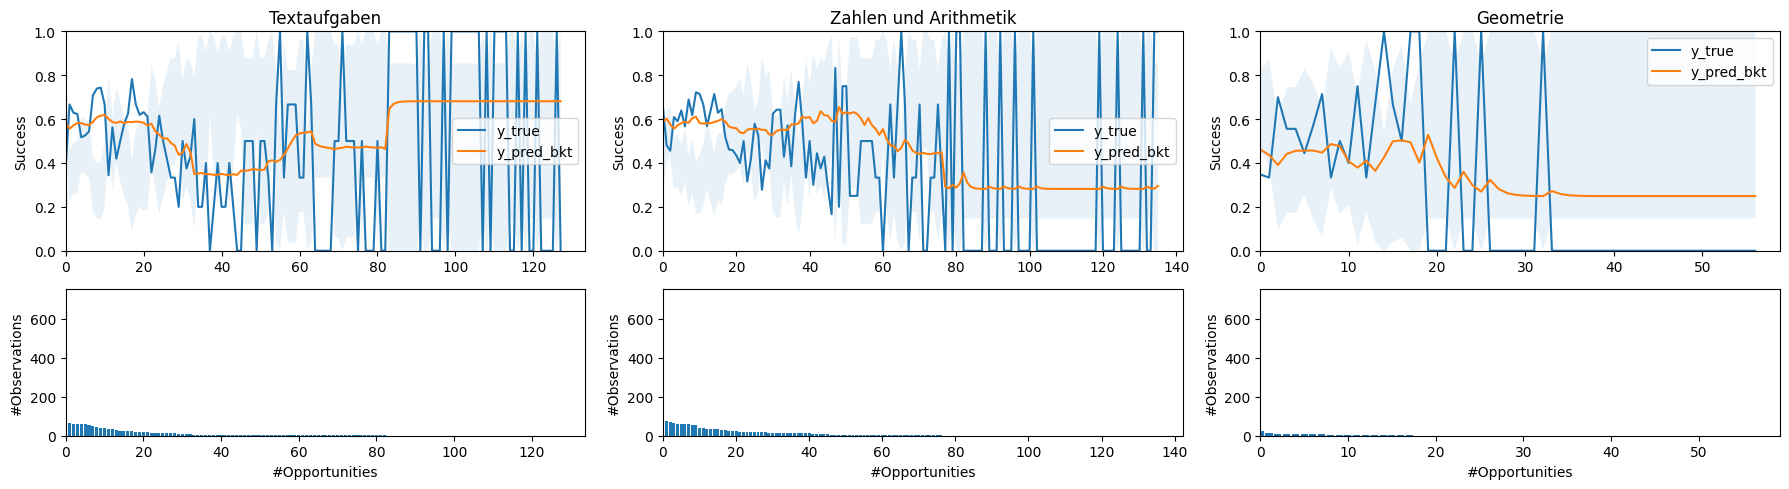

-------------------------------------------------------------------------------------------------------------------------------------------------
=== Light-AI ===


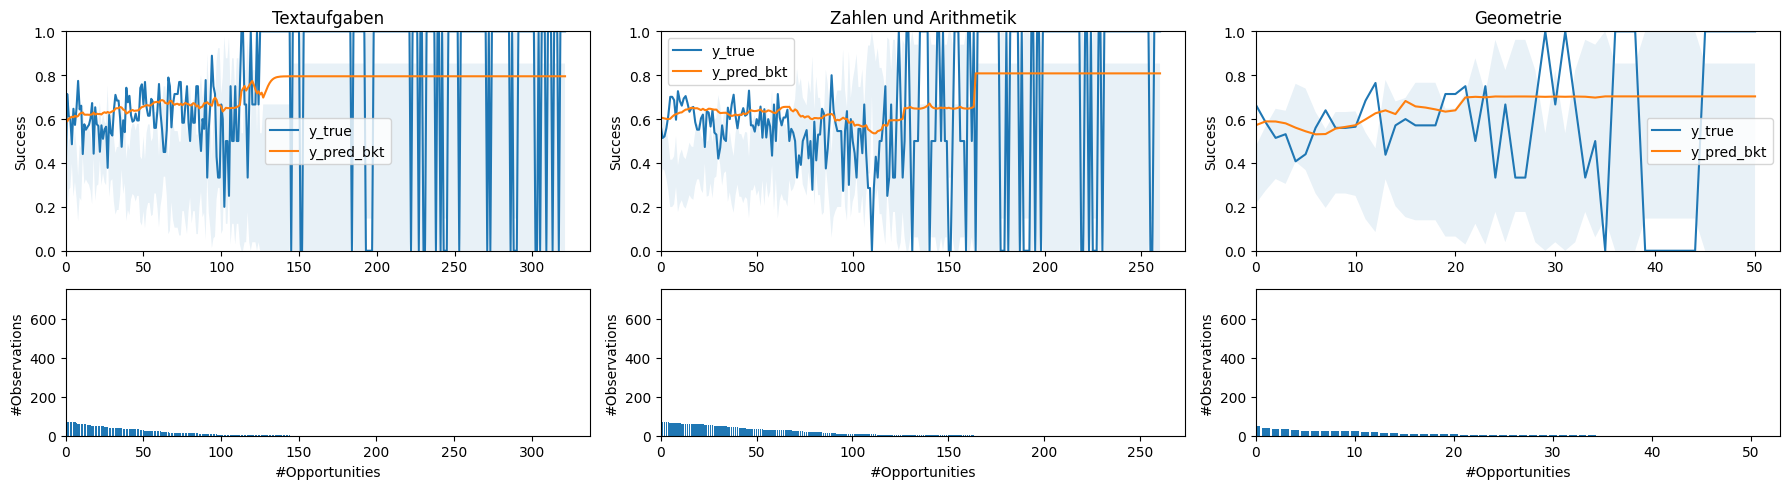

-------------------------------------------------------------------------------------------------------------------------------------------------
=== Heavy-AI ===


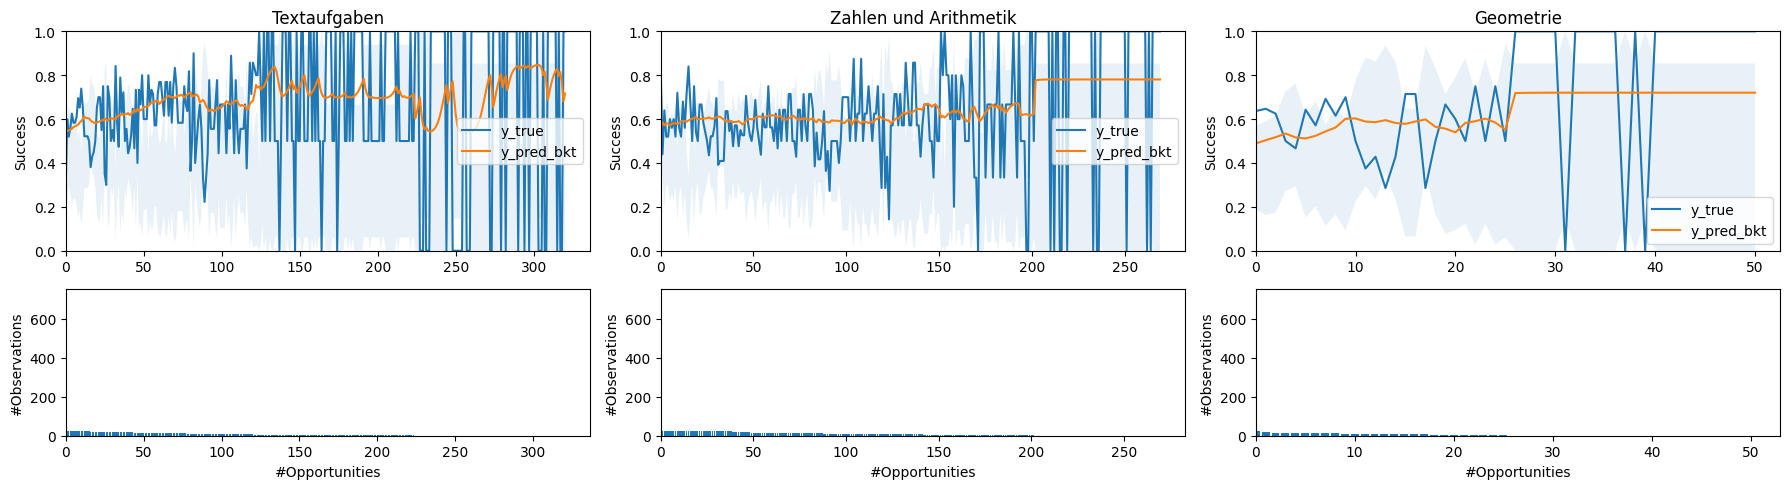

In [9]:
# plot_learning_curve('math')

#skills_subset = ['Textaufgaben','Zahlen und Arithmetik','Geometrie']
#for skill_name in skills_subset: # For the first three skills under consideration
#    plot_learning_curve(skill_name)


skills_subset = ['Textaufgaben', 'Zahlen und Arithmetik', 'Geometrie']

print("=== Non-AI ===")
plot_learning_curves_for_dataset(predictions1, skills_subset)
print(145* '-')

print("=== Light-AI ===")
plot_learning_curves_for_dataset(predictions2, skills_subset)
print(145* '-')

print("=== Heavy-AI ===")
plot_learning_curves_for_dataset(predictions3, skills_subset)





In [10]:

import seaborn as sns
from sklearn.metrics import mean_squared_error, roc_auc_score


def plot_metrics(df_preds, model_col='y_pred_bkt', y_col='y_true'):
    """
    Plot RMSE and AUC metrics (overall and per skill) for BKT predictions.
    
    Parameters:
        df_preds : DataFrame
            Must contain columns: ['skill_name', y_col, model_col]
        model_col : str
            Name of the prediction column (e.g., 'y_pred_bkt')
        y_col : str
            Name of the true label column (e.g., 'y_true')
    """
    # Compute per-skill RMSE and AUC
    skill_rmse = df_preds.groupby('skill_name').apply(
        lambda df: mean_squared_error(df[y_col], df[model_col], squared=False)
    )

    skill_auc = df_preds.groupby('skill_name').apply(
        lambda df: roc_auc_score(df[y_col], df[model_col])
    )

    print(f"RMSE: mean = {np.mean(skill_rmse):.4f}, std = {np.std(skill_rmse):.4f}")
    print(f"AUC:  mean = {np.mean(skill_auc):.4f}, std = {np.std(skill_auc):.4f}")

    # Bar plots
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(x=['All Skills']*len(skill_rmse), y=skill_rmse.values, ax=axes[0], ci='sd')
    axes[0].set_title('Overall RMSE')
    axes[0].set_ylabel('RMSE')
    axes[0].set_xlabel('')

    sns.barplot(x=skill_rmse.index, y=skill_rmse.values, ax=axes[1])
    axes[1].set_title('RMSE across skills')
    axes[1].set_ylabel('RMSE')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(x=['All Skills']*len(skill_auc), y=skill_auc.values, ax=axes[0], ci='sd')
    axes[0].set_title('Overall AUC')
    axes[0].set_ylabel('AUC')
    axes[0].set_xlabel('')

    sns.barplot(x=skill_auc.index, y=skill_auc.values, ax=axes[1])
    axes[1].set_title('AUC across skills')
    axes[1].set_ylabel('AUC')
    axes[1].set_xlabel('')
    axes[1].tick_params(axis='x', rotation=90)

    plt.tight_layout()
    plt.show()


=== Non-AI ===
RMSE: mean = 0.4722, std = 0.0076
AUC:  mean = 0.6732, std = 0.0225


/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/tmp/ipykernel_135/2138230204.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclu

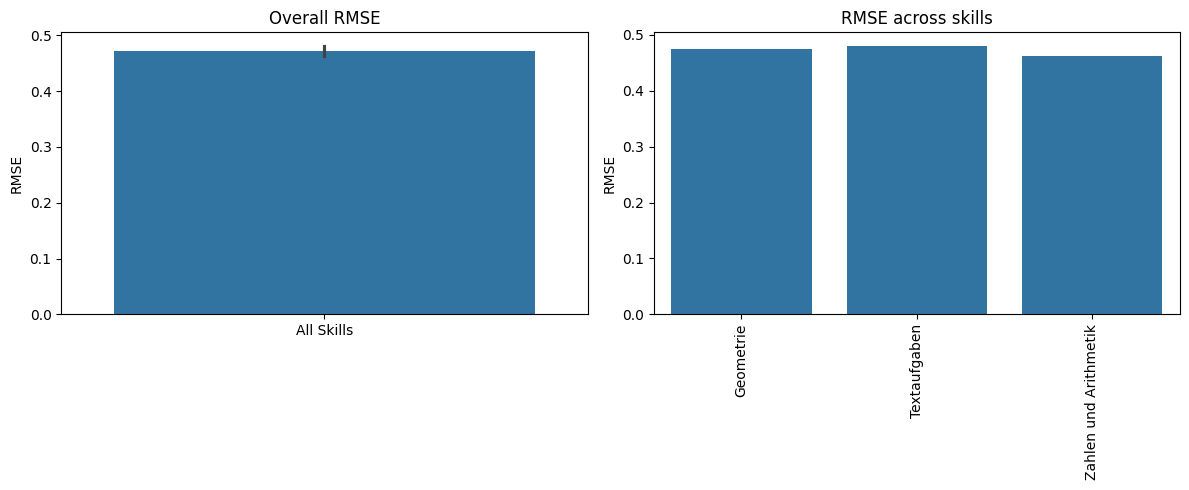

/tmp/ipykernel_135/2138230204.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=['All Skills']*len(skill_auc), y=skill_auc.values, ax=axes[0], ci='sd')


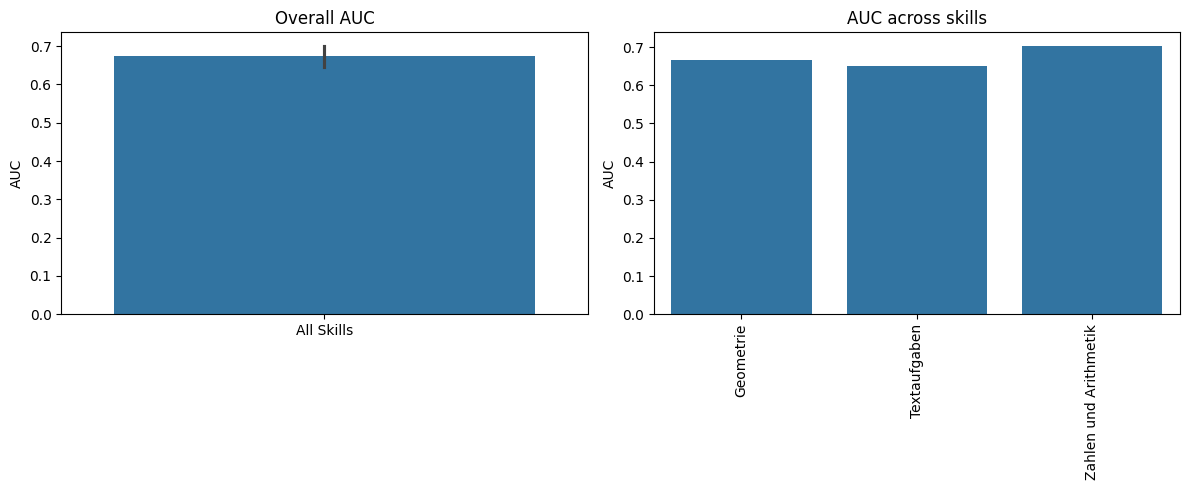

=== Light-AI ===
RMSE: mean = 0.4746, std = 0.0069
AUC:  mean = 0.6550, std = 0.0358


/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/tmp/ipykernel_135/2138230204.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclu

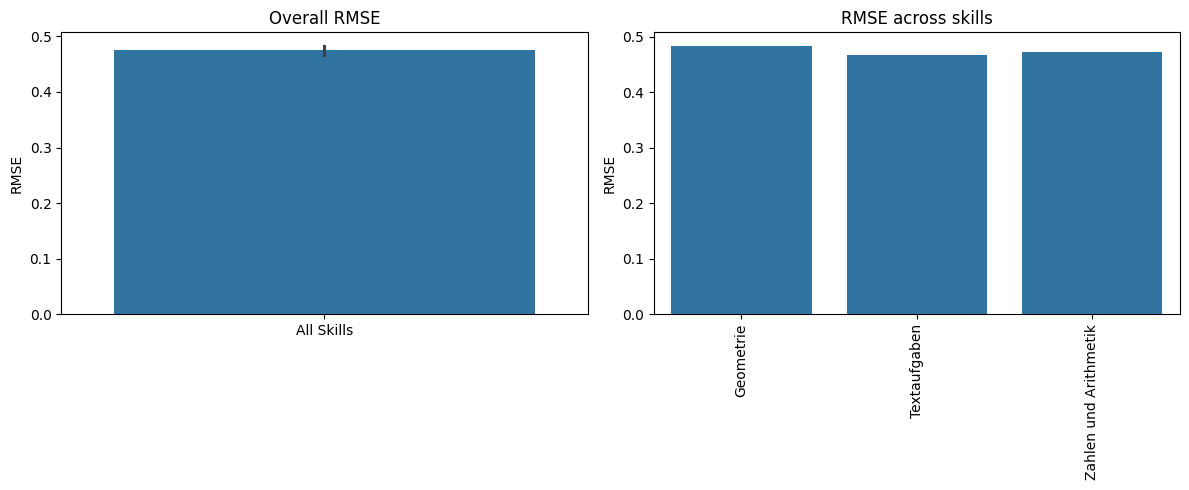

/tmp/ipykernel_135/2138230204.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=['All Skills']*len(skill_auc), y=skill_auc.values, ax=axes[0], ci='sd')


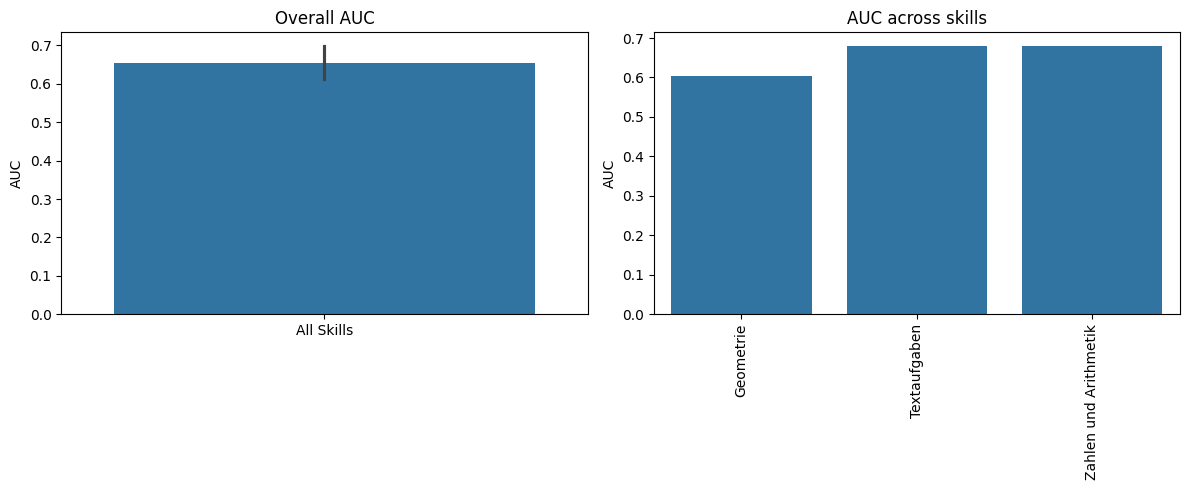

=== Heavy-AI ===
RMSE: mean = 0.4722, std = 0.0019
AUC:  mean = 0.6783, std = 0.0046


/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/tmp/ipykernel_135/2138230204.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be exclu

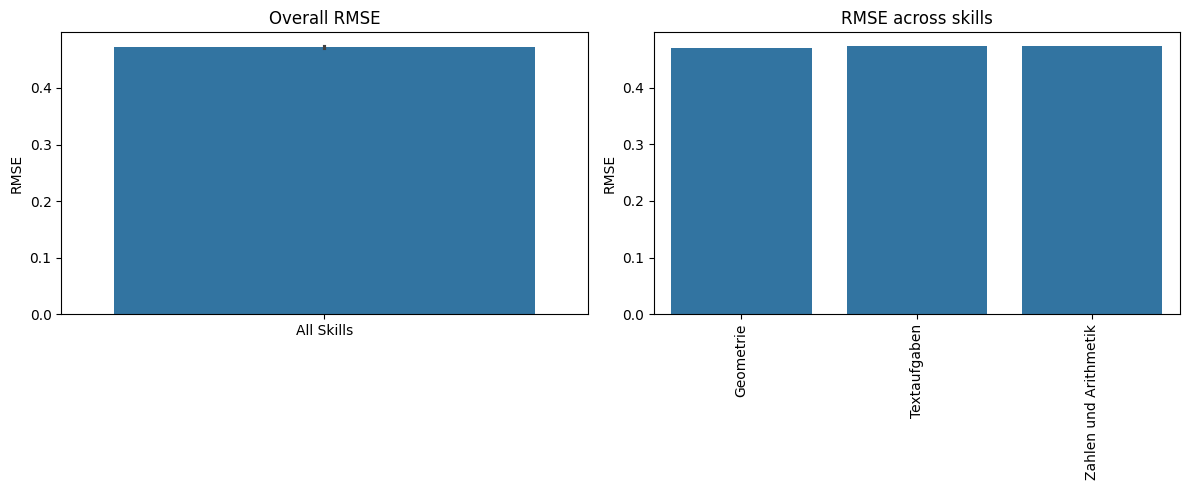

/tmp/ipykernel_135/2138230204.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(x=['All Skills']*len(skill_auc), y=skill_auc.values, ax=axes[0], ci='sd')


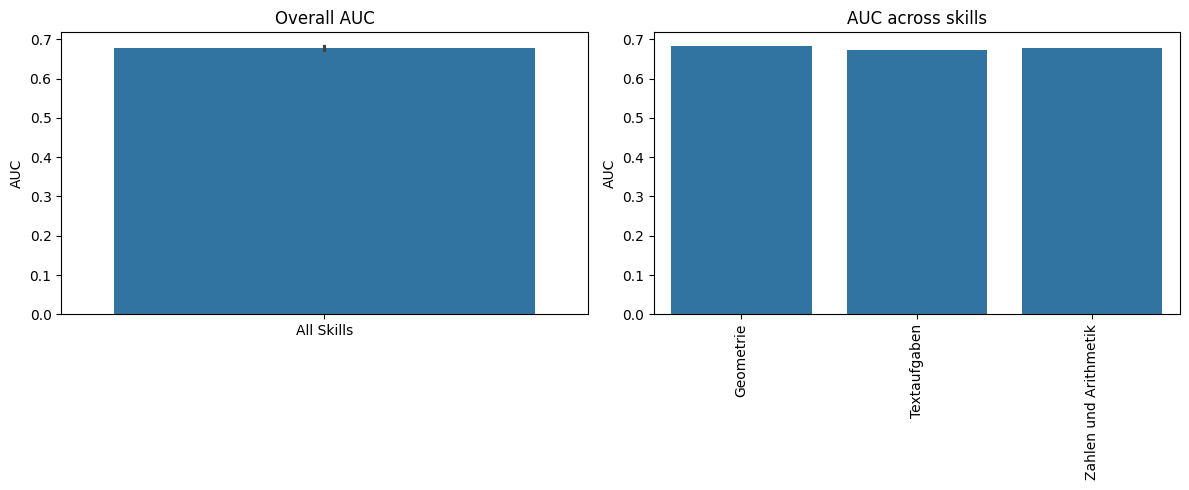

In [11]:
print("=== Non-AI ===")
plot_metrics(predictions1)
print("=== Light-AI ===")
plot_metrics(predictions2)
print("=== Heavy-AI ===")
plot_metrics(predictions3)

In [61]:
# display(df_heavy_ai_math.head())

selected_columns = ['user_id', 'timestamp', 'skill_id', 'correct', 'aux',
                    'prev_attempts', 'correct_aux', 'before_correct_num',
                    'before_wrong_num', 'source']  

df_non_ai_math['source'] = 'non_ai'
df_light_ai_math['source'] = 'light_ai'
df_heavy_ai_math['source'] = 'heavy_ai'

df_combined = pd.concat([df_non_ai_math, df_light_ai_math, df_heavy_ai_math], ignore_index=True)

df_filtered = df_combined[selected_columns].copy()
df_filtered = df_filtered.rename(columns={'skill_id': 'skill_name'})
df_filtered = df_filtered.rename(columns={'timestamp': 'order_id'})

df_filtered['source'] = df_filtered['source'].astype('category') 
df_filtered['source'] = df_filtered['source'].cat.reorder_categories(
    ['non_ai', 'light_ai', 'heavy_ai'],
    ordered=False
)


display(df_filtered)
print(df_combined['source'].value_counts())



,user_id,order_id,skill_name,correct,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,source
0,1,1730512029,Textaufgaben,0,1,0,0,0,0,non_ai
1,1,1730512029,Textaufgaben,1,1,1,1,0,1,non_ai
2,1,1730512029,Textaufgaben,0,1,2,1,1,1,non_ai
3,1,1730512029,Textaufgaben,1,1,3,2,1,2,non_ai
4,1,1730512029,Zahlen und Arithmetik,1,1,0,1,0,0,non_ai
...,...,...,...,...,...,...,...,...,...,...
56128,4087,1736091909,Zahlen und Arithmetik,1,1,94,62,61,33,heavy_ai
56129,4087,1736091909,Geometrie,1,1,11,9,8,3,heavy_ai
56130,4087,1736091909,Zahlen und Arithmetik,1,1,95,63,62,33,heavy_ai
56131,4087,1736091909,Zahlen und Arithmetik,1,1,96,64,63,33,heavy_ai


source
light_ai    27498
heavy_ai    16028
non_ai      12607
Name: count, dtype: int64


In [62]:
df_filtered['source'].cat.categories

Index(['non_ai', 'light_ai', 'heavy_ai'], dtype='object')

In [63]:
# Obtain indexes
train_index, test_index = next(create_iterator(df_filtered))
# Split the data
X_train, X_test = df_filtered.iloc[train_index], df_filtered.iloc[test_index]

display(X_train.head())
display(X_test.head())

,user_id,order_id,skill_name,correct,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,source
13,22,1730302184,Textaufgaben,0,1,0,0,0,0,non_ai
14,22,1730302184,Textaufgaben,1,1,1,1,0,1,non_ai
15,22,1730302184,Textaufgaben,1,1,2,2,1,1,non_ai
16,22,1730302184,Textaufgaben,1,1,3,3,2,1,non_ai
17,22,1730302184,Zahlen und Arithmetik,1,1,0,1,0,0,non_ai


,user_id,order_id,skill_name,correct,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,source
0,1,1730512029,Textaufgaben,0,1,0,0,0,0,non_ai
1,1,1730512029,Textaufgaben,1,1,1,1,0,1,non_ai
2,1,1730512029,Textaufgaben,0,1,2,1,1,1,non_ai
3,1,1730512029,Textaufgaben,1,1,3,2,1,2,non_ai
4,1,1730512029,Zahlen und Arithmetik,1,1,0,1,0,0,non_ai


In [59]:
# Import the lmm model class
from pymer4.models import Lmer

# Initialize and fit the model
#model = Lmer("correct ~ (1|user_id) + (1|skill_name) + (0 + before_correct_num|skill_name) + (0 + before_wrong_num|skill_name)", data=df_filtered, family='binomial')
model = Lmer("correct ~ source + (1|user_id) + (1|skill_name) + (0 + before_correct_num | skill_name) + (0 + before_wrong_num | skill_name)",data=df_filtered,family='binomial')

%time model.fit() 
# Compute predictions
# df_filtered['pfa_predictions'] = model.predict(data=df_filtered, verify_predictions=False)
df_filtered['pfa_predictions'] = model.predict(data=df_filtered, verify_predictions=False, skip_data_checks=True)

df_filtered.head()

/opt/jlab-env/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: correct~source+(1|user_id)+(1|skill_name)+(0+before_correct_num|skill_name)+(0+before_wrong_num|skill_name)

Family: binomial	 Inference: parametric

Number of observations: 56133	 Groups: {'user_id': 594.0, 'skill_name': 3.0}

Log-likelihood: -34941.363 	 AIC: 69896.727

Random effects:

                            Name     Var     Std
user_id              (Intercept) 0.57000 0.75500
skill_name           (Intercept) 0.00800 0.09100
skill_name.1  before_correct_num 0.00000 0.02000
skill_name.2    before_wrong_num 0.00000 0.02200

No random effect correlations specified

Fixed effects:

CPU times: user 2min 32s, sys: 1min 18s, total: 3min 50s
Wall time: 2min 29s


,user_id,order_id,skill_name,correct,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,source,pfa_predictions
0,1,1730512029,Textaufgaben,0,1,0,0,0,0,non_ai,0.62160
1,1,1730512029,Textaufgaben,1,1,1,1,0,1,non_ai,0.62037
2,1,1730512029,Textaufgaben,0,1,2,1,1,1,non_ai,0.62180
3,1,1730512029,Textaufgaben,1,1,3,2,1,2,non_ai,0.62057
4,1,1730512029,Zahlen und Arithmetik,1,1,0,1,0,0,non_ai,0.61275


In [60]:
model.fixef  # sabit (fixed) etkiler

[      (Intercept)  sourcelight_ai  sourceheavy_ai  before_correct_num  \
 1         0.42992         0.02941        -0.12451             0.00000   
 6        -0.02809         0.02941        -0.12451             0.00000   
 7         0.04965         0.02941        -0.12451             0.00000   
 9         0.27068         0.02941        -0.12451             0.00000   
 11        0.49708         0.02941        -0.12451             0.00000   
 ...           ...             ...             ...                 ...   
 4086      1.11290         0.02941        -0.12451             0.00000   
 4087      0.75004         0.02941        -0.12451             0.00000   
 4089      0.72090         0.02941        -0.12451             0.00000   
 4092     -0.24728         0.02941        -0.12451             0.00000   
 4095     -0.48033         0.02941        -0.12451             0.00000   
 
       before_wrong_num  
 1              0.00000  
 6              0.00000  
 7              0.00000  
 9    

In [64]:
# Import the lmm model class
from pymer4.models import Lmer

# Initialize and fit the model
model = Lmer("correct ~ source +  (1|user_id) + (1|skill_name) + (0 + prev_attempts|skill_name)", data=df_filtered, family='binomial')
%time model.fit() 
# Compute predictions
df_filtered['afm_predictions'] = model.predict(data=df_filtered, verify_predictions=False, skip_data_checks=True)
df_filtered.head()

[1] "Model failed to converge with max|grad| = 0.0295307 (tol = 0.002, component 1)"
[2] " \n"                                                                           

[1] "Model is nearly unidentifiable: very large eigenvalue\n - Rescale variables?"
[2] " \n"                                                                         



/opt/jlab-env/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: correct~source+(1|user_id)+(1|skill_name)+(0+prev_attempts|skill_name)

Family: binomial	 Inference: parametric

Number of observations: 56133	 Groups: {'user_id': 594.0, 'skill_name': 3.0}

Log-likelihood: -35009.271 	 AIC: 70030.542

Random effects:

                       Name     Var     Std
user_id         (Intercept) 0.65000 0.80600
skill_name      (Intercept) 0.01300 0.11500
skill_name.1  prev_attempts 0.00000 0.00100

No random effect correlations specified

Fixed effects:

CPU times: user 9min 51s, sys: 54.2 s, total: 10min 45s
Wall time: 9min 51s


,user_id,order_id,skill_name,correct,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,source,afm_predictions
0,1,1730512029,Textaufgaben,0,1,0,0,0,0,non_ai,0.62081
1,1,1730512029,Textaufgaben,1,1,1,1,0,1,non_ai,0.62103
2,1,1730512029,Textaufgaben,0,1,2,1,1,1,non_ai,0.62124
3,1,1730512029,Textaufgaben,1,1,3,2,1,2,non_ai,0.62145
4,1,1730512029,Zahlen und Arithmetik,1,1,0,1,0,0,non_ai,0.61432


In [65]:
model.fixef  # sabit (fixed) etkiler

[      (Intercept)  sourcelight_ai  sourceheavy_ai  prev_attempts
 1         0.41418         0.05622        -0.09757        0.00000
 6        -0.09474         0.05622        -0.09757        0.00000
 7         0.00100         0.05622        -0.09757        0.00000
 9         0.23548         0.05622        -0.09757        0.00000
 11        0.55124         0.05622        -0.09757        0.00000
 ...           ...             ...             ...            ...
 4086      1.23002         0.05622        -0.09757        0.00000
 4087      0.75757         0.05622        -0.09757        0.00000
 4089      0.69719         0.05622        -0.09757        0.00000
 4092     -0.28095         0.05622        -0.09757        0.00000
 4095     -0.57493         0.05622        -0.09757        0.00000
 
 [594 rows x 4 columns],
                        (Intercept)  sourcelight_ai  sourceheavy_ai  \
 Geometrie                  0.29895         0.05622        -0.09757   
 Textaufgaben               0.53812    

In [16]:
X_test.groupby('skill_name')['prev_attempts'].nunique()

skill_name
Geometrie                 57
Textaufgaben             128
Zahlen und Arithmetik    136
Name: prev_attempts, dtype: int64

In [109]:
# Import the lmm model class
from pymer4.models import Lmer

# Initialize and fit the model
#model = Lmer("correct ~ (1|user_id) + (1|skill_name) + (0 + prev_attempts|skill_name)", data=X_train, family='binomial')

model = Lmer("correct ~ (1|user_id) + (1|skill_name) + prev_attempts", data=X_train, family='binomial')
%time model.fit() 
# Compute predictions
X_test['afm_predictions'] = model.predict(data=X_test, verify_predictions=False)
X_test.head()

[1] "Model is nearly unidentifiable: very large eigenvalue\n - Rescale variables?"
[2] " \n"                                                                         

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: correct~(1|user_id)+(1|skill_name)+prev_attempts

Family: binomial	 Inference: parametric

Number of observations: 9727	 Groups: {'user_id': 184.0, 'skill_name': 3.0}

Log-likelihood: -5883.350 	 AIC: 11774.700

Random effects:

                   Name     Var     Std
user_id     (Intercept) 0.97700 0.98900
skill_name  (Intercept) 0.05500 0.23400

No random effect correlations specified

Fixed effects:

CPU times: user 22.4 s, sys: 27.5 s, total: 49.9 s
Wall time: 25.7 s


/opt/jlab-env/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,user_id,order_id,skill_name,correct,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,afm_predictions
1187,56,1739898029,Textaufgaben,1,1,0,1,0,0,0.64082
1188,56,1739898029,Geometrie,0,1,0,0,0,0,0.54552
1189,56,1739898029,Textaufgaben,1,1,1,2,1,0,0.64067
1190,56,1739898029,Textaufgaben,0,1,2,2,2,0,0.64053
1191,56,1739898029,Textaufgaben,0,1,3,2,2,1,0.64038


In [95]:
print("Train columns:", X_train.columns.tolist())
print("Test columns:", X_test.columns.tolist())

Train columns: ['user_id', 'order_id', 'skill_name', 'correct', 'aux', 'prev_attempts', 'correct_aux', 'before_correct_num', 'before_wrong_num']
Test columns: ['user_id', 'order_id', 'skill_name', 'correct', 'correct_predictions', 'state_predictions']


In [24]:
# Data processing
# Number of attempts before current
def preprocess_data(data):
    data['aux'] = 1
    data['prev_attempts'] = data.sort_values('order_id').groupby(['user_id', 'skill_name'])['aux'].cumsum() -1

    # Number of correct and incorrect attempts before current attempt
    data['correct_aux'] = data.sort_values('order_id').groupby(['user_id', 'skill_name'])['correct'].cumsum()
    data['before_correct_num'] = data.sort_values('order_id').groupby(['user_id', 'skill_name'])['correct_aux'].shift(periods=1, fill_value=0)
    data['before_wrong_num'] = data['prev_attempts'] - data['before_correct_num']
    return data

data = preprocess_data(data)
data.head()

,user_id,order_id,skill_name,correct,correct_predictions,state_predictions,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,7,1,math,0,0.59716,0.30482,1,0,0,0,0
1,7,2,math,1,0.55696,0.16059,1,1,1,0,1
2,7,3,math,1,0.57637,0.23025,1,2,2,1,1
3,7,4,math,1,0.60080,0.31789,1,3,3,2,1
4,7,5,math,1,0.62930,0.42014,1,4,4,3,1


In [25]:
data.head(15)

,user_id,order_id,skill_name,correct,correct_predictions,state_predictions,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num
0,7,1,math,0,0.59716,0.30482,1,0,0,0,0
1,7,2,math,1,0.55696,0.16059,1,1,1,0,1
2,7,3,math,1,0.57637,0.23025,1,2,2,1,1
3,7,4,math,1,0.60080,0.31789,1,3,3,2,1
4,7,5,math,1,0.62930,0.42014,1,4,4,3,1
5,7,6,math,0,0.65975,0.52938,1,5,4,4,1
6,7,7,math,0,0.60340,0.32721,1,6,4,4,2
7,7,8,math,1,0.56093,0.17485,1,7,5,4,3
8,7,9,math,0,0.58151,0.24867,1,8,5,5,3
9,7,10,math,1,0.54751,0.12672,1,9,6,5,4


In [26]:
def create_iterator(data):
    '''
    Create an iterator to split interactions in data into train and test, with the same student not appearing in two diverse folds.
    :param data:        Dataframe with student's interactions.
    :return:            An iterator.
    '''    
    # Both passing a matrix with the raw data or just an array of indexes works
    X = np.arange(len(data.index)) 
    # Groups of interactions are identified by the user id (we do not want the same user appearing in two folds)
    groups = data['user_id'].values 
    return model_selection.GroupShuffleSplit(n_splits=1, train_size=.8, test_size=0.2, random_state=0).split(X, groups=groups)

In [27]:
# Obtain indexes
train_index, test_index = next(create_iterator(data))
# Split the data
X_train, X_test = data.iloc[train_index], data.iloc[test_index]

In [31]:
# Import the lmm model class
from pymer4.models import Lmer

# Initialize and fit the model
# model = Lmer("correct ~ (1|user_id) + (1|skill_name) + (0 + prev_attempts|skill_name)", data=X_train, family='binomial')

model = Lmer("correct ~ prev_attempts + (1|user_id)", data=X_train, family='binomial')

%time model.fit() 
# Compute predictions
X_test['afm_predictions'] = model.predict(data=X_test, verify_predictions=False)
X_test.head()

[1] "Model is nearly unidentifiable: very large eigenvalue\n - Rescale variables?"
[2] " \n"                                                                         

Linear mixed model fit by maximum likelihood  ['lmerMod']
Formula: correct~prev_attempts+(1|user_id)

Family: binomial	 Inference: parametric

Number of observations: 21403	 Groups: {'user_id': 189.0}

Log-likelihood: -13283.691 	 AIC: 26573.381

Random effects:

                Name     Var     Std
user_id  (Intercept) 0.50200 0.70900

No random effect correlations specified

Fixed effects:

CPU times: user 22.4 s, sys: 24.9 s, total: 47.3 s
Wall time: 24.7 s


/opt/jlab-env/lib/python3.12/site-packages/pymer4/models/Lmer.py:733: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ran_vars = ran_vars.applymap(


,user_id,order_id,skill_name,correct,correct_predictions,state_predictions,aux,prev_attempts,correct_aux,before_correct_num,before_wrong_num,afm_predictions
518,20,1,math,0,0.59716,0.30482,1,0,0,0,0,0.65298
519,20,2,math,0,0.55696,0.16059,1,1,0,0,1,0.65281
520,20,3,math,0,0.53405,0.07841,1,2,0,0,2,0.65265
521,20,4,math,1,0.52276,0.03792,1,3,1,0,3,0.65248
522,20,5,math,1,0.52893,0.06005,1,4,2,1,3,0.65231


In [32]:
def plot_metrics(df_preds, model):

    # Compute RMSE and AUC per skill
    skill_rmse = df_preds.groupby(['skill_name']).apply(lambda df_preds: mean_squared_error(df_preds.correct, df_preds[model], squared=False))
    print('RMSE', np.mean(skill_rmse), np.std(skill_rmse))

    skill_auc = df_preds.groupby(['skill_name']).apply(lambda df_preds: roc_auc_score(df_preds.correct, df_preds[model]))
    print('AUC', np.mean(skill_auc), np.std(skill_auc))

    # Create overall RMSE and RMSE per skill data frames
    skills_all = ['Skills']*len(skills_subset)
    df_overall_rmse = pd.DataFrame(list(zip(skills_all, skill_rmse)),
                   columns =['x', 'RMSE'])
    df_skill_rmse = pd.DataFrame(list(zip(skills_subset, skill_rmse)),
                   columns =['x', 'RMSE'])

    # Create overall AUC and AUC per skill data frames
    df_overall_auc = pd.DataFrame(list(zip(skills_all, skill_auc)),
                   columns =['x', 'AUC'])
    df_skill_auc = pd.DataFrame(list(zip(skills_subset, skill_auc)),
                   columns =['x', 'AUC'])

    # Two bar plots for RMSE: first one with std (mean RMSE over all skills), then one bar plot with a bar for each specific skill
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    sns.barplot(ax=axes[0],x='x', y='RMSE', data=df_overall_rmse, estimator=np.mean, ci='sd')
    axes[0].set_title('Overall RMSE')
    axes[0].set_xlabel('')

    sns.barplot(ax=axes[1],x='x', y='RMSE', data=df_skill_rmse, estimator=np.mean, ci='sd')
    plt.xticks(rotation=90)
    axes[1].set_title('RMSE across skills')
    axes[1].set_xlabel('')

    fig.show()

    # Two bar plots for AUC: first one with std (mean AUC over all skills), then one bar plot with a bar for each specific skill
    fig, axes = plt.subplots(1, 2, figsize=(10,5))
    sns.barplot(ax=axes[0],x='x', y='AUC', data=df_overall_auc, estimator=np.mean, ci='sd')
    axes[0].set_title('Overall AUC')
    axes[0].set_xlabel('')

    sns.barplot(ax=axes[1],x='x', y='AUC', data=df_skill_auc, estimator=np.mean, ci='sd')
    plt.xticks(rotation=90)
    axes[1].set_title('AUC across skills')
    axes[1].set_xlabel('')

    fig.show()

/opt/jlab-env/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
/tmp/ipykernel_126/3311973062.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  skill_rmse = df_preds.groupby(['skill_name']).apply(lambda df_preds: mean_squared_error(df_preds.correct, df_preds[model], squared=False))
/tmp/ipykernel_126/3311973062.py:7: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from th

RMSE 0.4966237111404916 0.0
AUC 0.5417136525558787 0.0


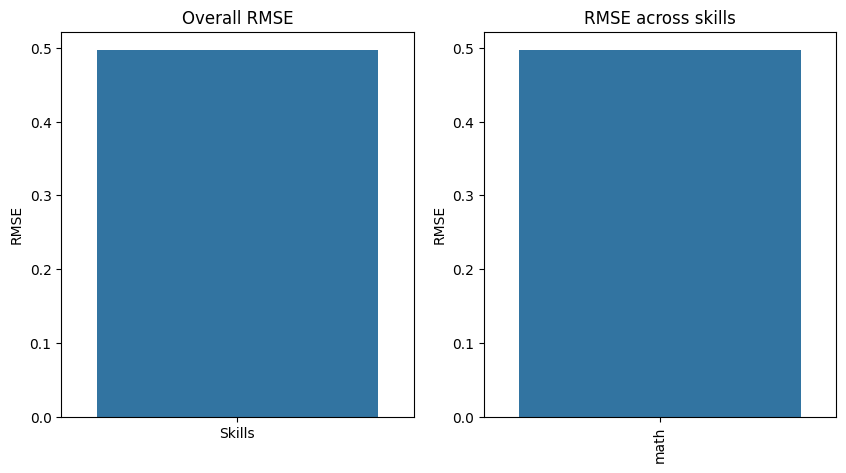

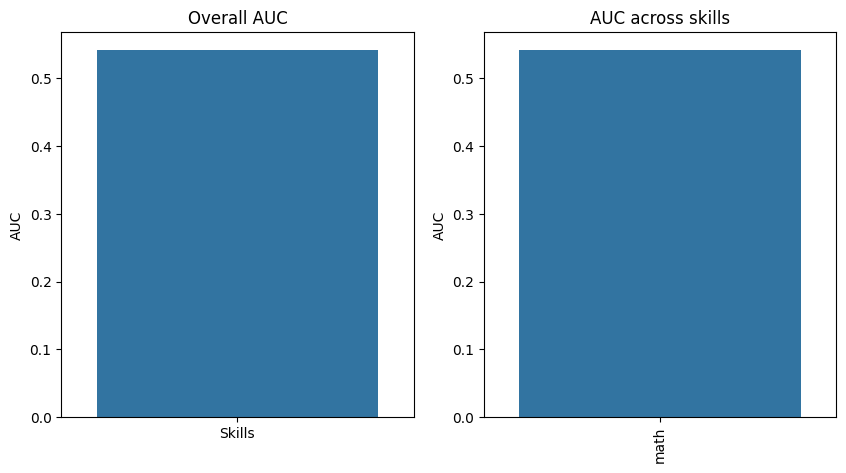

In [34]:
skills_subset = ['math']
plot_metrics(X_test, 'afm_predictions')

In [12]:
from pyBKT.models import Model
import pandas as pd

def prepare_pyBKT_format(df, user_col='user_id', skill_col='skill_id', correct_col='correct'):
    """Prepare data for pyBKT format"""
    data = df[[user_col, skill_col, correct_col]].copy()
    data.columns = ['user_id', 'skill_name', 'correct']
    return data

# Filter all_data_categorical to only contain skills that are observed enough 
# (i.e. at least 50 interactions with the skills)
skill_counts = all_data_categorical['skill_id'].value_counts()
valid_skills = skill_counts[skill_counts >= 50].index.tolist()
all_data_categorical = all_data_categorical[all_data_categorical['skill_id'].isin(valid_skills)]

non_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'non_ai_user']
light_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'light_ai_user']
heavy_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'heavy_ai_user']

non_ai_data = prepare_pyBKT_format(non_ai_users)
light_ai_data = prepare_pyBKT_format(light_ai_users)
heavy_ai_data = prepare_pyBKT_format(heavy_ai_users)

def train_bkt(df):
    model = Model(seed=42)  # reproducible results
    model.fit(data=df)
    return model

bkt_non_ai = train_bkt(non_ai_data)
bkt_light_ai = train_bkt(light_ai_data)
bkt_heavy_ai = train_bkt(heavy_ai_data)

import matplotlib.pyplot as plt
import numpy as np

def predict_learning_curve(model, df, label):
    preds = model.predict(data=df)
    preds_correct = preds['correct_predictions']
    
    avg_correct = []
    window = 10
    preds_correct = preds_correct.tolist()
    
    for i in range(0, len(preds_correct), window):
        avg_correct.append(np.mean(preds_correct[i:i+window]))
    return avg_correct

non_ai_curve = predict_learning_curve(bkt_non_ai, non_ai_data, 'Non-AI Users')
light_ai_curve = predict_learning_curve(bkt_light_ai, light_ai_data, 'Light-AI Users')
heavy_ai_curve = predict_learning_curve(bkt_heavy_ai, heavy_ai_data, 'Heavy-AI Users')

# Plot
plt.figure(figsize=(10,6))
plt.plot(non_ai_curve, label='Non-AI Users')
plt.plot(light_ai_curve, label='Light-AI Users')
plt.plot(heavy_ai_curve, label='Heavy-AI Users')
plt.title('BKT Learning Curves by AI Usage (pyBKT)')
plt.xlabel('Interaction Window (50 steps)')
plt.ylabel('Average Predicted Correctness')
plt.xlim(0, 500)
plt.grid()
plt.legend()
plt.show()

NameError: name 'all_data_categorical' is not defined

*Your discussion about your model training goes here*

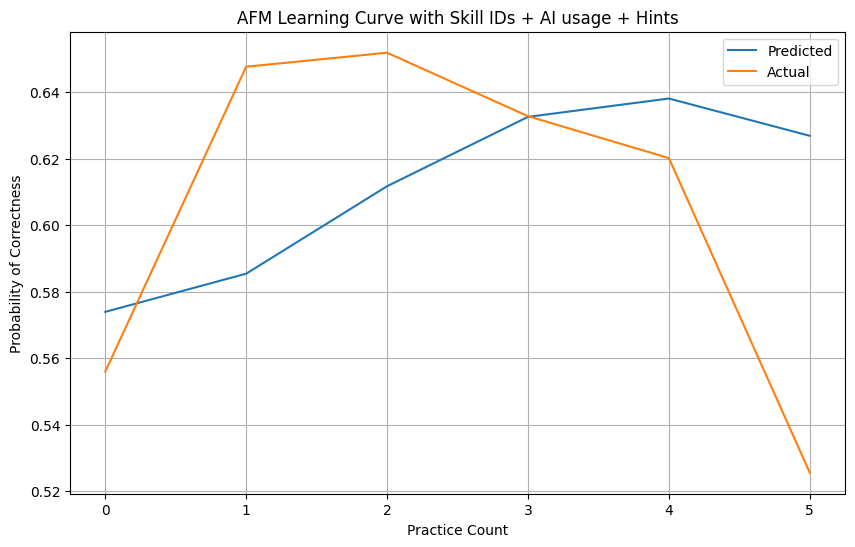

practice_count
0     39876
1     10920
2      4160
3      1664
4       861
5       451
6       230
7       137
8       114
9        70
10       47
11       42
12       40
13       27
14       26
15       23
16       22
17       16
18       14
19       12
20       10
21        9
22        7
23        4
24        3
25        2
26        1
27        1
28        1
29        1
30        1
Name: count, dtype: int64


In [6]:
#AFM
from sklearn.linear_model import LogisticRegression

def prepare_afm_features(df):
    """Prepare features for AFM modeling."""
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    df['practice_count'] = df.groupby(['user_id', 'skill_id']).cumcount()
    
    if 'hint_used' not in df.columns:
        df['hint_used'] = 0  # No hints for essay
    if 'ai_message_count' not in df.columns:
        df['ai_message_count'] = 0
    
    features = df[['practice_count', 'hint_used', 'ai_message_count', 'skill_id']].copy()
    X = pd.get_dummies(features, columns=['skill_id'])  # One-hot encode skill
    y = df['correct']
    
    return X, y

X_afm, y_afm = prepare_afm_features(all_data_categorical)

afm_model = LogisticRegression(max_iter=1000)
afm_model.fit(X_afm, y_afm)

y_pred_probs = afm_model.predict_proba(X_afm)[:,1]

def plot_learning_curve(X, y_true, y_pred_probs, title="AFM Learning Curve"):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs
    df_plot = df_plot[df_plot['practice_count'] <= 5]
    
    avg_pred = df_plot.groupby('practice_count')['pred'].mean()
    avg_true = df_plot.groupby('practice_count')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index, avg_pred.values, label='Predicted')
    plt.plot(avg_true.index, avg_true.values, label='Actual')
    plt.title(title)
    plt.xlabel('Practice Count')
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_learning_curve(X_afm, y_afm, y_pred_probs, title="AFM Learning Curve with Skill IDs + AI usage + Hints")

print(X_afm['practice_count'].value_counts().sort_index())

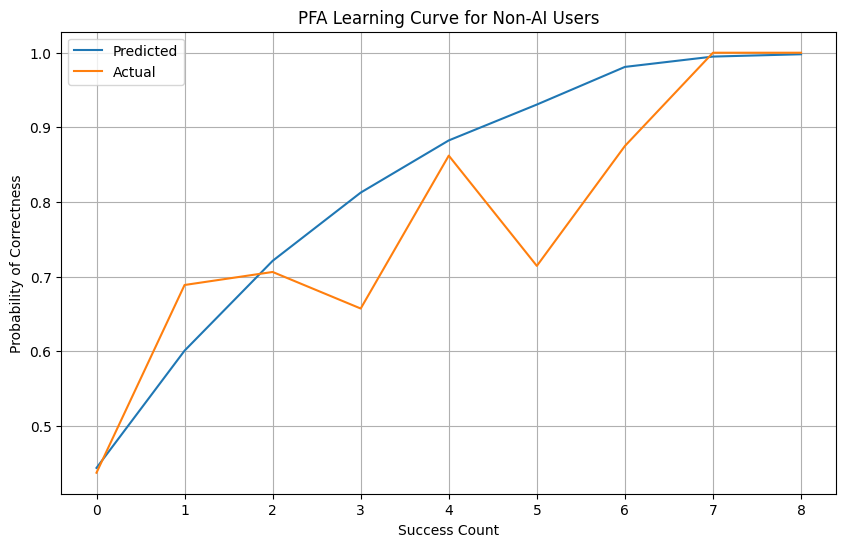

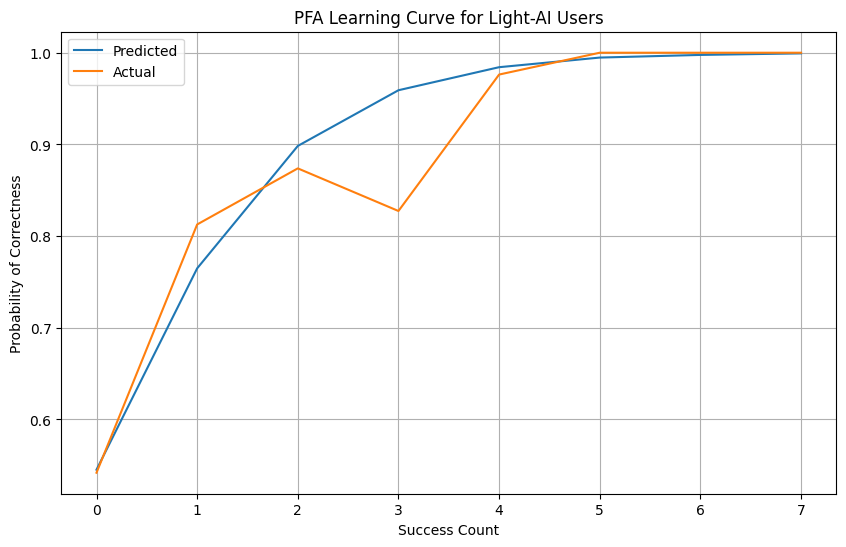

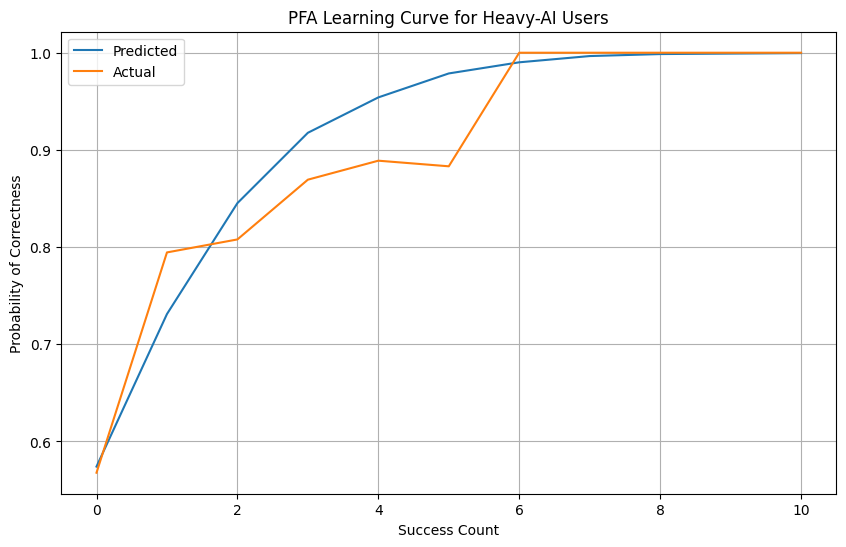

In [7]:
# PFA
from sklearn.linear_model import LogisticRegression

def prepare_pfa_features(df):
    """Prepare features for PFA modeling."""
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    df['success_count'] = 0
    df['failure_count'] = 0
    user_skill_groups = df.groupby(['user_id', 'skill_id'])
    for (user, skill), group in user_skill_groups:
        successes = 0
        failures = 0
        for idx in group.index:
            df.at[idx, 'success_count'] = successes
            df.at[idx, 'failure_count'] = failures
            if df.at[idx, 'correct'] == 1:
                successes += 1
            else:
                failures += 1
    if 'hint_used' not in df.columns:
        df['hint_used'] = 0
    if 'ai_message_count' not in df.columns:
        df['ai_message_count'] = 0

    feature_cols = ['success_count', 'failure_count', 'hint_used', 'ai_message_count']
    X = df[feature_cols]
    y = df['correct']
    return X, y

non_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'non_ai_user']
light_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'light_ai_user']
heavy_ai_users = all_data_categorical[all_data_categorical['ai_usage_category'] == 'heavy_ai_user']

non_ai_data_X, non_ai_data_y = prepare_pfa_features(non_ai_users)
light_ai_data_X, light_ai_data_y = prepare_pfa_features(light_ai_users)
heavy_ai_data_X, heavy_ai_data_y = prepare_pfa_features(heavy_ai_users)

# # All the students together
# X_pfa, y_pfa = prepare_pfa_features(all_data_categorical)

def train_pfa(X, y_true):
    pfa_model = LogisticRegression(max_iter=1000)
    pfa_model.fit(X, y_true)
    y_pred_probs = pfa_model.predict_proba(X)[:,1]
    return y_pred_probs

non_ai_data_y_pred = train_pfa(non_ai_data_X, non_ai_data_y)
light_ai_data_y_pred = train_pfa(light_ai_data_X, light_ai_data_y)
heavy_ai_data_y_pred = train_pfa(heavy_ai_data_X, heavy_ai_data_y)

# Plot 
import matplotlib.pyplot as plt

def plot_pfa_learning_curve(X, y_true, y_pred_probs, title="PFA Learning Curve"):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs

    df_plot = df_plot[df_plot['success_count'] <= 10]  # limit to low success counts where we have data

    avg_pred = df_plot.groupby('success_count')['pred'].mean()
    avg_true = df_plot.groupby('success_count')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index, avg_pred.values, label='Predicted')
    plt.plot(avg_true.index, avg_true.values, label='Actual')
    plt.title(title)
    plt.xlabel('Success Count')
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_pfa_learning_curve(non_ai_data_X, non_ai_data_y, non_ai_data_y_pred, "PFA Learning Curve for Non-AI Users")
plot_pfa_learning_curve(light_ai_data_X, light_ai_data_y, light_ai_data_y_pred, "PFA Learning Curve for Light-AI Users")
plot_pfa_learning_curve(heavy_ai_data_X, heavy_ai_data_y, heavy_ai_data_y_pred, "PFA Learning Curve for Heavy-AI Users")

In [10]:
# DKT
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Step 1: Prepare DKT sequences
def prepare_dkt_sequences(df):
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])
    
    # Encode skills into integer indices
    from sklearn.preprocessing import LabelEncoder
    skill_encoder = LabelEncoder()
    df['skill_id_encoded'] = skill_encoder.fit_transform(df['skill_id'])

    sequences = []
    labels = []
    
    grouped = df.groupby('user_id')
    for user, group in grouped:
        skill_seq = group['skill_id_encoded'].tolist()
        correct_seq = group['correct'].tolist()
        combined_seq = [(skill, correct) for skill, correct in zip(skill_seq, correct_seq)]
        sequences.append(combined_seq)

    return sequences, skill_encoder

sequences, skill_encoder = prepare_dkt_sequences(all_data_categorical)

# Encode sequences
n_skills = len(skill_encoder.classes_)
max_seq_len = 100  # max number of interactions per user (can adjust)

X = []
y = []
for seq in sequences:
    input_seq = []
    output_seq = []
    for (skill, correct) in seq:
        input_id = skill + (correct * n_skills)  # clever trick: skill_id + n_skills if correct=1
        input_seq.append(input_id)
        output_seq.append(correct)
    X.append(input_seq)
    y.append(output_seq)

X_pad = pad_sequences(X, maxlen=max_seq_len, padding='post', value=2 * n_skills)  # pad with unknown ID
y_pad = pad_sequences(y, maxlen=max_seq_len, padding='post', value=-1)

# Step 2: Build DKT model
model = Sequential([
    Masking(mask_value=2 * n_skills, input_shape=(max_seq_len,)),
    LSTM(100, return_sequences=True),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam')

# Step 3: Prepare inputs/outputs
X_train, X_test, y_train, y_test = train_test_split(X_pad, y_pad, test_size=0.2, random_state=42)

# DKT expects one-hot inputs
from tensorflow.keras.utils import to_categorical

X_train_onehot = to_categorical(X_train, num_classes=2 * n_skills + 1)
X_test_onehot = to_categorical(X_test, num_classes=2 * n_skills + 1)

# Flatten outputs
y_train_flat = y_train.reshape((-1,))
y_test_flat = y_test.reshape((-1,))
mask_train = y_train_flat != -1
mask_test = y_test_flat != -1

# Train only on valid steps
history = model.fit(X_train_onehot.reshape((-1, max_seq_len, 2 * n_skills + 1)),
                    y_train_flat[mask_train],
                    epochs=10,
                    batch_size=64,
                    validation_data=(X_test_onehot.reshape((-1, max_seq_len, 2 * n_skills + 1)), y_test_flat[mask_test]))

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# EXTRA PLOTS JUST FOR COMPARISON

In [14]:
# iBKT/individualized-BKT

# 1. First, train a normal BKT model
def train_bkt_basic(df):
    model = Model(seed=42)
    model.fit(data=df)
    return model

# 2. Then, compute per-user average residuals and add a user bias
def train_ibkt(df):
    bkt_model = train_bkt_basic(df)
    preds = bkt_model.predict(data=df)
    df['predicted'] = preds['correct_predictions']
    df['residual'] = df['correct'] - df['predicted']

    user_bias = df.groupby('user_id')['residual'].mean().to_dict()

    return bkt_model, user_bias

# 3. Prediction function
def predict_ibkt(model, user_bias, df):
    preds = model.predict(data=df)
    preds['correct_predictions_ibkt'] = preds['correct_predictions']

    # Add user bias
    preds['correct_predictions_ibkt'] += preds['user_id'].map(user_bias).fillna(0)

    # Clip predictions between [0,1]
    preds['correct_predictions_ibkt'] = preds['correct_predictions_ibkt'].clip(0, 1)

    return preds

# Example usage:
# Prepare data
def prepare_pyBKT_format(df):
    df = df[['user_id', 'skill_id', 'correct']].copy()
    df.columns = ['user_id', 'skill_name', 'correct']
    return df

# Prepare your dataset
filtered_data = all_data_categorical.copy()
filtered_data_simple = prepare_pyBKT_format(filtered_data)

# Train
bkt_model, user_bias = train_ibkt(filtered_data_simple)

# Predict
preds_ibkt = predict_ibkt(bkt_model, user_bias, filtered_data_simple)

/tmp/ipykernel_118/2350771811.py:46: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_pred = df_plot.groupby('history_bin')['pred'].mean()
/tmp/ipykernel_118/2350771811.py:47: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_true = df_plot.groupby('history_bin')['true'].mean()


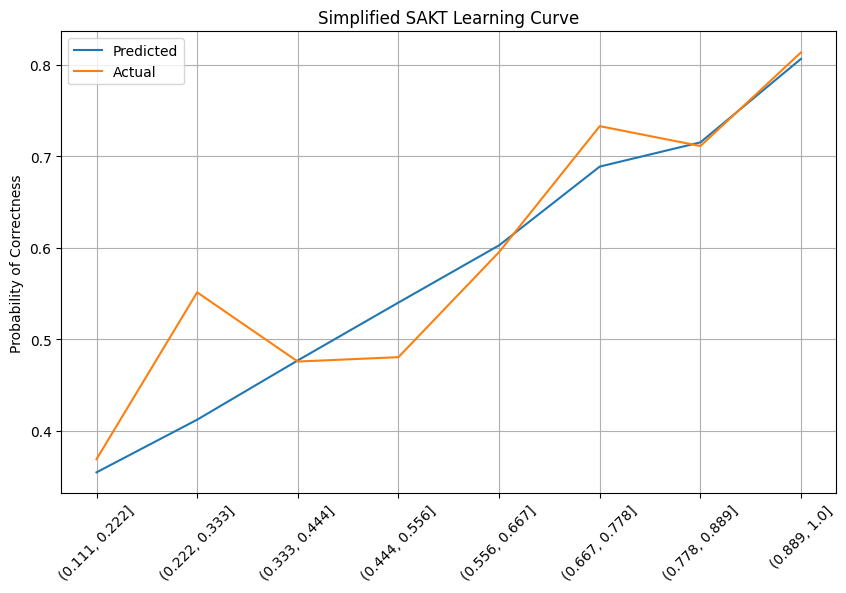

In [12]:
#Mini-SAKT
from sklearn.linear_model import LogisticRegression

# 1. Prepare interaction history
def prepare_sakt_features(df, window_size=5):
    df = df.copy()
    df = df.sort_values(['user_id', 'timestamp'])

    df['history_correct_mean'] = 0.5  # initialize

    user_groups = df.groupby('user_id')
    for user, group in user_groups:
        correct_history = []
        for idx in group.index:
            if len(correct_history) == 0:
                df.at[idx, 'history_correct_mean'] = 0.5  # no history
            else:
                df.at[idx, 'history_correct_mean'] = np.mean(correct_history[-window_size:])
            correct_history.append(df.at[idx, 'correct'])

    features = df[['history_correct_mean']]
    labels = df['correct']
    return features, labels

# Prepare features
X_sakt, y_sakt = prepare_sakt_features(all_data_categorical)

# 2. Train logistic regression on history
sakt_model = LogisticRegression(max_iter=1000)
sakt_model.fit(X_sakt, y_sakt)

# 3. Predict
y_pred_probs_sakt = sakt_model.predict_proba(X_sakt)[:,1]

# 4. Plot (optional)
import matplotlib.pyplot as plt

def plot_sakt_learning_curve(X, y_true, y_pred_probs):
    df_plot = X.copy()
    df_plot['true'] = y_true
    df_plot['pred'] = y_pred_probs

    bins = np.linspace(0, 1, 10)
    df_plot['history_bin'] = pd.cut(df_plot['history_correct_mean'], bins)

    avg_pred = df_plot.groupby('history_bin')['pred'].mean()
    avg_true = df_plot.groupby('history_bin')['true'].mean()

    plt.figure(figsize=(10,6))
    plt.plot(avg_pred.index.astype(str), avg_pred.values, label='Predicted')
    plt.plot(avg_true.index.astype(str), avg_true.values, label='Actual')
    plt.xticks(rotation=45)
    plt.title("Simplified SAKT Learning Curve")
    plt.ylabel('Probability of Correctness')
    plt.grid()
    plt.legend()
    plt.show()

plot_sakt_learning_curve(X_sakt, y_sakt, y_pred_probs_sakt)

## Task 3: Model Evaluation
In this task, you will use metrics to evaluate your model.

In [ ]:
# Your code for model evaluation goes here

*Your discussion/interpretation about your model's behavior goes here*

## Task 4: Team Reflection
Please describe the contributions of each team member to Milestone 4. Reflect on how you worked as team: what went well, what can be improved for the next milestone?

*Your discussion about team responsibilities goes here*